In [ ]:
# Genom att köra detta program så blir alla tabeller nedan vänsterjusterade
from IPython.core.display import HTML
table_css = 'table {align:left;display:block} '
HTML('<style>{}</style>'.format(table_css))

# Bestämning av formel för periodtiden för en stav i svängning
Datum: 2026-10-07

Laboranter: Hugo Schön, Agnes Hall, Noëlle Lööv

## Syfte
Bestämma en formel för svängningstiden (Periodtid) med hjälp av dimensionsanalys och mätningar.

## Teori
Formeln antas kunna skrivas på formen:
$$ T = k \cdot A^{x_A} \cdot l^{x_l} \cdot w^{x_w} \cdot h^{x_h} \cdot g^{x_g} \cdot \rho^{x_\rho} \cdot E^{x_E} \quad \mathrm{(1)}$$

där $k$ är en dimensionslös konstant och $A$, $l$, $w$, $h$ etc. är oberoende variabler som antas kunna påverka periodtiden. Exponenterna $x_A$, $x_l$ etc. kan bestämmas med hjälp av mätningar och/eller dimensionsanalys.

Den sökta variabeln $T$ har dimensionen $\mathbf{T}$. I tabell 1 nedan listas de oberoende variabler som antas kunna påverka periodtiden $T$ för stavarna.

Tabell 1: Oberoende variabler. För respektive variabel anges dess variabelbeteckning och dimension. Dimensionerna uttrycks i de tre grundläggande dimensionerna längd ($\mathbf{L}$), massa ($\mathbf{M}$) och tid ($\mathbf{T}$).
| Beskrivning |   SI-enhet   | Variabelbeteckning | Dimension |
|:-----------:|:------------:|:------------------:|:---------:|
| Amplitud    | $\mathrm{m}$ | $A$                | $\mathbf{L}$|
| Längd       | $\mathrm{m}$ | $l$                | $\mathbf{L}$|
| Bredd       | $\mathrm{m}$ | $w$                | $\mathbf{L}$|
| Tjocklek    | $\mathrm{m}$ | $h$                | $\mathbf{L}$|
| Tyngdacceleration | $\frac{\mathrm{m}}{\mathrm{s^2}}$ | $g$           | $\mathbf{LT}^{-2}$|
| Densitet    | $\frac{\mathrm{kg}}{\mathrm{m^3}}$        | $\rho$      | $\mathbf{ML}^{-3}$|
| Elasticitet | $\frac{\mathrm{kg}}{\mathrm{ms^2}}$ | $E$ | $\mathbf{ML}^{-1}\mathbf{T}^{-2}$|

Ovanstående formel ger följande dimensionssamband:
$$\mathbf{T}^1 \cdot \mathbf{M}^0 \cdot \mathbf{L}^0 = 1 \cdot \mathbf{L}^{x_A} \cdot \mathbf{L}^{x_l} \cdot \mathbf{L}^{x_w} \cdot \mathbf{L}^{x_h} \cdot (\mathbf{LT}^{-2})^{x_g} \cdot (\mathbf{ML}^{-3})^{x_\rho} \cdot (\mathbf{ML}^{-1}\mathbf{T}^{-2})^{x_E} \quad \mathrm{(2)}$$

För att vänster- och högerled ska ha samma dimenstion så måste exponenterna i vänsterledet och högerledet för dimensionerna längd, massa och tid vara lika. Vi får därmed följande tre ekvationsvillkor:
$$ \mathbf{L}:\ 0 = x_A + x_l + x_w + x_h + x_g - 3x_\rho - x_E \quad \mathrm{(3)} $$
$$ \mathbf{M}:\ 0 = x_\rho + x_E \quad \mathrm{(4)} $$
$$ \mathbf{T}:\ 1 = -2x_g - 2x_E \quad \mathrm{(5)} $$

Då ovanstående tre ekvationer innehåller sju okända exponenter behöver minst fyra av exponenterna bestämmas genom mätningar för att resterande tre exponenter ska kunna beräknas med hjälp av ovanstående tre ekvationer.

Om vi linjäriserar ekvation (1) kan vi beräkna exponenternas värden genom linjär regression. Vi kan skriva ekvation (1) på linjär form genom att ta den naturliga logaritmen ur båda leden:
$$\ln(T) = \ln(k \cdot A^{x_A} \cdot l^{x_l} \cdot w^{x_w} \cdot h^{x_h} \cdot g^{x_g} \cdot \rho^{x_\rho} \cdot E^{x_E}) \quad \mathrm{(6)} $$
I våra mätserier håller vi alla variabler utom en, exempelvis $l$, konstanta. Vi kan därmed skriva ekvationen i formen 
$$ \ln(T) = x_l \ln(l) + \ln(k \cdot A^{x_A} \cdot w^{x_w} \cdot h^{x_h} \cdot g^{x_g} \cdot \rho^{x_\rho} \cdot E^{x_E}) \quad \mathrm{(7)} $$
Därefter kan vi skriva produkten av konstanterna som variabeln $C_l$, vilket ger formeln
$$ \ln(T) = x_l \ln(l) + \ln(C_l) \quad \mathrm{(8)} $$

## Metod

### Utrustning

Tabell 2: Utrustningen som har använts under laborationen
| Nummer i figur 1 | Beskrivning:        |Kommentar:                                              |
|:----------------:|:-------------------:|:------------------------------------------------------:|
| 1                | Mätrigg             |                                                        |
| 2                | Stavar av stål      | Stavar av stål i varierande tjocklek, bredd och längd. |
| 3                | Fotocell            | Pasco ME-9215A. Fotocell med elektroniskt tidtagarur.  |
|                  | Mjukvara för analys | Python (faktisk kod finns på GitHub, inte exakt samma form som den i notebooken) |
|                  | Linjal              | Noggranhet: 0.5mm, gjord i trä av Nordstedt            |
|                  | Skjutmått           | Noggranhet: 0.05mm                                     |

![Principskiss av labbuppställningen](./lab_setup.png)
*Figur 1: Principskiss av labbuppställningen*

### Utförande
Laborationen börjar med att identifiera de oberoende storheter som skulle kunna påverka periodtiden för staven. Ett samband för periodtiden antas sedan som dimensionsanalysen utgår från. Dimensionsanalysen resulterar i tre ekvationer. Eftersom vi har tre ekvationer i ekvationsystemet så kan tre obekanta beräknas från det. Av de sju oberoende variablerna kan fyra varieras och mätas med tillgänglig utrustning: $A$, $l$, $w$ och $h$. Resterande tre oberoende variabler, $g$, $\rho$ och $E$, hölls konstanta under samtliga mätningar. Värdena på $g$, $\rho$, och $E$ antogs vara $9.82 \mathrm{m/s^2}$, $7850 \mathrm{kg/m^3}$ och $200 \mathrm{GPa}$ respektive, baserat på information från labbhandledare.


Utförande av laborationen:
En stav av stål fästes i  mätriggen sådan att den sticker ut åt vänster (se figur 1). Fotocellen placeras sedan i änden av staven. Höjden på fotocellen justeras sådant att den röda lampan lyser konstant när staven inte rör sig. Staven trycks sedan ner, därefter släpps den, vilket får staven att vibrera. Ett flertal mätningar av periodtiden utförs med fotocellen, som återställs upprepade gånger, först tills värdet börjar stabilisera sig och sedan ett antal gånger till för att få mätvärden. Det värdet som antecknas är en uppskattning av medelvärdet av de stabila mätningarna. För att bestämma exponenterna $x_A$, $x_l$, $x_w$ och $x_h$ utförs fyra mätserier. I mätserierna undersöks hur periodtiden påverkas när en variabel varieras medans övriga variabler hålls konstanta. Det som justeras under laborationen är alltså amplituden, hur långt staven böjs innan den släpps, längden, hur långt staven sticker ut från fästpunkten, liksom vilken stav som används, då de har olika tjocklekar och bredd.

Efter varje mätserie pluggas de uppmätta värdena in i vår python-kod för att räkna ut riktningskoefficienten enligt ekvation (8) med linjär regression. Värdet som fås ut avrundas till närmsta halvtal och sparas som exponent för den relevanta variabeln.

Baserat på ekvationssystemet av ekvationer (3-5) räknas sedan de tre sista exponenterna fram efter att vi har beräknat de vi kan mäta experimentellt.

Slutligen beräknas $k$ genom att alla uppmätta variabler och beräknade exponenter stoppas in i ekvation (1), varefter ett genomsnittligt $k$ beräknas genom linjär regression.

# Resultat

Nedan presenteras resultaten från mätningarna. Under samtliga mätningar var värdet för tyngdacceleration, densitet och elasticitetsmodul konstant.

$\mathrm{g = 9.82m/s^2}$ $\mathrm{\rho = 7850kg/m^3}$ $\mathrm{E = 200GPa} $

## Mätserie 1 - variation av amplitud
De variablar som hölls konstanta var: l=0.696m, b:0.0202m, h: 0.00515m

I tabell 3 redovisas den uppmätta periodtiden för olika amplituder.

Tabell 3: Periodtiden för olika amplituder.
| Amplitud (m) | Periodtid (s)|
|:----------:|:-------------:|
| 0.01       | 0.123         |
| 0.02       | 0.123         |
| 0.03       | 0.123         |
| 0.04       | 0.123         |
| 0.05       | 0.123         |

Vi sätter $x=\ln(A)$ och $y=\ln(T)$ och plottar mätvärdena i en $xy$-graf, se figur 1. Den räta linjen i figuren är anpassad till mätvärdena med minstakvadratmetoden. Riktningskoefficienten för den anpassade räta linjen fås till -7 * 10^-15, vilket innebär att exponenten $x_A$ bör vara 0. Vi mäter därför inte amplituden i senare mätserier.

slope 1: -7.037301933996981e-15 ± 4.1e-15
intercept 1: -2.0955709236097455 ± 1.5e-14


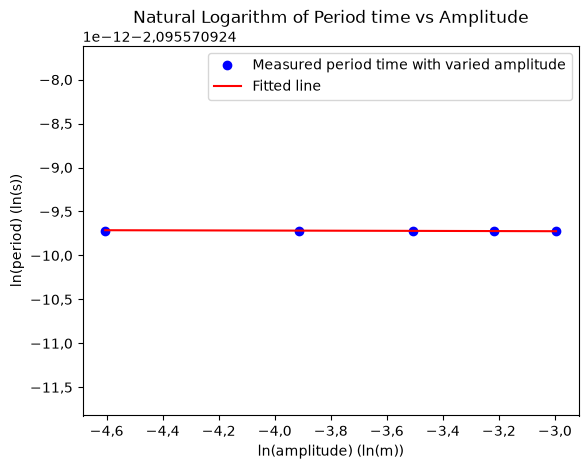

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Set pyplot to use Swedish locale for numeric formatting
import locale
_, axes = plt.subplots()
locale.setlocale(locale.LC_NUMERIC, ('sv_SE', 'UTF-8'))
axes.ticklabel_format(useLocale=True)

def linReg(x: np.ndarray, y: np.ndarray):
  """
  Performs linear regression on the given x and y data.
  x: independent variable (numpy array)
  y: dependent variable (numpy array)

  Returns: (k1, k2, u1, u2)
  k1: slope of the fitted line
  k2: intercept of the fitted line
  u1: uncertainty in the slope
  u2: uncertainty in the intercept
  """
  n = len(x)
  k1: int | float = (n*np.sum(x*y)-np.sum(x)*np.sum(y)) / ( n*np.sum(x**2)-np.sum(x)**2)
  k2: int | float = (np.sum(y) - (k1 * np.sum(x))) / n

  # Standard deviation for the regression
  dev = np.sqrt((1 / (n - 2)) * np.sum((y - (k1 * x) - k2) ** 2))
  meanX = np.mean(x)
  # Uncertainty in slope
  u1: int | float = dev * np.sqrt(1/np.sum((x - meanX) ** 2))
  # Uncertainty in intercept
  u2: int | float = dev * np.sqrt((1/n) + ((meanX ** 2) / np.sum((x - meanX) ** 2)))

  return (k1, k2, u1, u2)

# First set of measured values; varying Amplitude (cm) and measuring period time (s)
amplitude_1 = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
period_1 = np.array([0.123, 0.123, 0.123, 0.123, 0.123])
# First set of constant values, all 3 are measured in cm
length_1 = np.array([69.6 for _ in range(5)])
width_1 = np.array([2.02 for _ in range(5)])
height_1 = np.array([0.515 for _ in range(5)])
# Convert to base units (remove prefix)
amplitude_1 *= 0.01
period_1 *= 1
length_1 *= 0.01
width_1 *= 0.01
height_1 *= 0.01

# Linearize by taking the natural logarithm of both values, then perform regression
slope, intercept, slope_uncertainty, intercept_uncertainty = linReg(np.log(amplitude_1), np.log(period_1))

# Print slope and intercept; we mainly care about slope
print(f'slope 1: {slope} ± {slope_uncertainty:.2g}')
print(f'intercept 1: {intercept} ± {intercept_uncertainty:.2g}')

plt.plot(np.log(amplitude_1), np.log(period_1), 'bo', label='Measured period time with varied amplitude')
plt.plot(np.log(amplitude_1), slope*np.log(amplitude_1) + intercept, 'r-', label='Fitted line')
plt.title('Natural Logarithm of Period time vs Amplitude')
plt.xlabel('ln(amplitude) (ln(m))')
plt.ylabel('ln(period) (ln(s))')
plt.legend()
plt.show()

## Mätserie 2 - variation av längd
I tabell 4 redovisas den uppmätta periodtiden för olika längder.

De variablar som hölls konstanta var: b:0.0202m, h: 0.00515m (Amp. Påverkar ej så räknas inte med)

Tabell  4: Periodtiden för olika längder.
| Längd (m)  | Periodtid (s)|
|:----------:|:------------:|
| 0.751m     | 0.141        |
| 0.696m     | 0.123        |
| 0.652m     | 0.107        |
| 0.6015m    | 0.092        |
| 0.5505     | 0.078        |

Vi sätter $x=\ln(l)$ och $y=\ln(T)$ och plottar mätvärdena i en $xy$-graf, se figur 2. Den räta linjen i figuren är anpassad till mätvärdena med minstakvadratmetoden. Riktningskoefficienten för den anpassade räta linjen fås till 1.934(38), vilket innebär att exponenten $x_l$ bör vara 2.

slope 2: 1.933862670648311 ± 0.038
intercept 2: -1.4036564514838479 ± 0.017


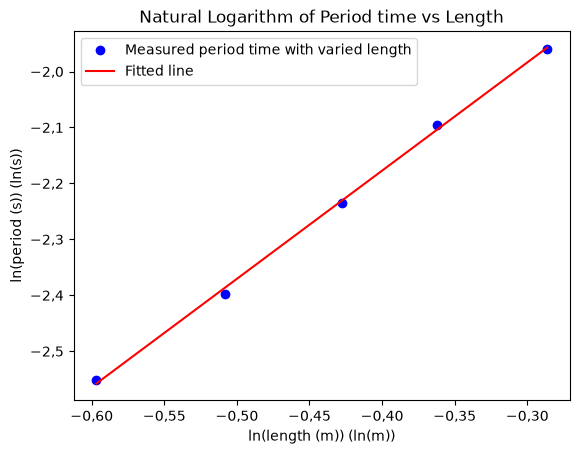

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Set pyplot to use Swedish locale for numeric formatting
import locale
_, axes = plt.subplots()
locale.setlocale(locale.LC_NUMERIC, ('sv_SE', 'UTF-8'))
axes.ticklabel_format(useLocale=True)

def linReg(x: np.ndarray, y: np.ndarray):
  """
  Performs linear regression on the given x and y data.
  x: independent variable (numpy array)
  y: dependent variable (numpy array)

  Returns: (k1, k2, u1, u2)
  k1: slope of the fitted line
  k2: intercept of the fitted line
  u1: uncertainty in the slope
  u2: uncertainty in the intercept
  """
  n = len(x)
  k1: int | float = (n*np.sum(x*y)-np.sum(x)*np.sum(y)) / ( n*np.sum(x**2)-np.sum(x)**2)
  k2: int | float = (np.sum(y) - (k1 * np.sum(x))) / n

  # Standard deviation for the regression
  dev = np.sqrt((1 / (n - 2)) * np.sum((y - (k1 * x) - k2) ** 2))
  meanX = np.mean(x)
  # Uncertainty in slope
  u1: int | float = dev * np.sqrt(1/np.sum((x - meanX) ** 2))
  # Uncertainty in intercept
  u2: int | float = dev * np.sqrt((1/n) + ((meanX ** 2) / np.sum((x - meanX) ** 2)))

  return (k1, k2, u1, u2)

# Second set of measured values; length (cm) and period time (s)
length_2 = np.array([55.05, 60.15, 65.2, 69.6, 75.1])
period_2 = np.array([0.078, 0.091, 0.107, 0.123, 0.141])
# Second set of constant values, both are measured in cm
width_2 = np.array([2.02 for _ in range(5)])
height_2 = np.array([0.515 for _ in range(5)])
# Convert to base units (remove prefix)
length_2 *= 0.01
period_2 *= 1
width_2 *= 0.01
height_2 *= 0.01

# Linearize by taking the natural logarithm of both values, then perform regression
slope, intercept, slope_uncertainty, intercept_uncertainty = linReg(np.log(length_2), np.log(period_2))

# Print slope and intercept; we mainly care about slope
print(f'slope 2: {slope} ± {slope_uncertainty:.2g}')
print(f'intercept 2: {intercept} ± {intercept_uncertainty:.2g}')

plt.plot(np.log(length_2), np.log(period_2), 'bo', label='Measured period time with varied length')
plt.plot(np.log(length_2), slope*np.log(length_2) + intercept, 'r-', label='Fitted line')
plt.title('Natural Logarithm of Period time vs Length')
plt.xlabel('ln(length (m)) (ln(m))')
plt.ylabel('ln(period (s)) (ln(s))')
plt.legend()
plt.show()

## Mätserie 3 - variation av bredd
I tabell 5 redovisas den uppmätta periodtiden för olika bredd.

De variablar som hölls konstanta var: l: 0.701 +- 0.0005m, h: 0.00355m (Amp påverkar ej.)

Tabell 5: Periodtiden för olika bredd.
| Bredd (m) | Periodtid (s)| längd (m) |
|:---------:|:------------:|:---------:|
| 0.0204    | 0.182        | (70.15cm) |
| 0.0302    | 0.185        | (70.05cm) |
| 0.0403    | 0.182        | (70.10cm) |
| 0.0500    | 0.188        | (70.10cm) |

Vi sätter $x=\ln(w)$ och $y=\ln(T)$ och plottar mätvärdena i en $xy$-graf, se figur 3. Den räta linjen i figuren är anpassad till mätvärdena med minstakvadratmetoden. Riktningskoefficienten för den anpassade räta linjen fås till 0.025(22), vilket innebär att exponenten $x_w$ bör vara 0.

slope 3: 0.025417767277625666 ± 0.022
intercept 3: -1.6051367196324762 ± 0.075


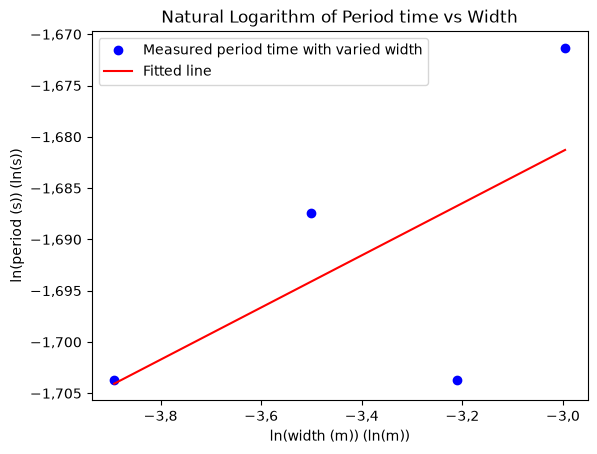

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Set pyplot to use Swedish locale for numeric formatting
import locale
_, axes = plt.subplots()
locale.setlocale(locale.LC_NUMERIC, ('sv_SE', 'UTF-8'))
axes.ticklabel_format(useLocale=True)

def linReg(x: np.ndarray, y: np.ndarray):
  """
  Performs linear regression on the given x and y data.
  x: independent variable (numpy array)
  y: dependent variable (numpy array)

  Returns: (k1, k2, u1, u2)
  k1: slope of the fitted line
  k2: intercept of the fitted line
  u1: uncertainty in the slope
  u2: uncertainty in the intercept
  """
  n = len(x)
  k1: int | float = (n*np.sum(x*y)-np.sum(x)*np.sum(y)) / ( n*np.sum(x**2)-np.sum(x)**2)
  k2: int | float = (np.sum(y) - (k1 * np.sum(x))) / n

  # Standard deviation for the regression
  dev = np.sqrt((1 / (n - 2)) * np.sum((y - (k1 * x) - k2) ** 2))
  meanX = np.mean(x)
  # Uncertainty in slope
  u1: int | float = dev * np.sqrt(1/np.sum((x - meanX) ** 2))
  # Uncertainty in intercept
  u2: int | float = dev * np.sqrt((1/n) + ((meanX ** 2) / np.sum((x - meanX) ** 2)))

  return (k1, k2, u1, u2)

# Third set of measured values; width (cm) and period time (s)
width_3 = np.array([2.04, 3.02, 4.03, 5.00])
period_3 = np.array([0.182, 0.185, 0.182, 0.188])
# Third set of constant values, both are measured in cm
# Length varies slightly due to human error in setting up the experiment
length_3 = np.array([70.15, 70.05, 70.1, 70.1])
height_3 = np.array([0.35 for _ in range(4)])
# Convert to base units (remove prefix)
width_3 *= 0.01
period_3 *= 1
length_3 *= 0.01
height_3 *= 0.01

# Linearize by taking the natural logarithm of both values, then perform regression
slope, intercept, slope_uncertainty, intercept_uncertainty = linReg(np.log(width_3), np.log(period_3))

# Print slope and intercept; we mainly care about slope
print(f'slope 3: {slope} ± {slope_uncertainty:.2g}')
print(f'intercept 3: {intercept} ± {intercept_uncertainty:.2g}')

plt.plot(np.log(width_3), np.log(period_3), 'bo', label='Measured period time with varied width')
plt.plot(np.log(width_3), slope*np.log(width_3) + intercept, 'r-', label='Fitted line')
plt.title('Natural Logarithm of Period time vs Width')
plt.xlabel('ln(width (m)) (ln(m))')
plt.ylabel('ln(period (s)) (ln(s))')
plt.legend()
plt.show()

## Mätserie 4 - variation av höjd

I tabell 6 redovisas den uppmätta periodtiden för olika höjder.

Den variabel som hölls konstanta var: l: 0.85 +- 0.0005m, då varken bredd eller amplitud påverkar. 

Tabell 6: Periodtiden för olika höjder.
| Höjd (m) | Periodtid (s)|
|:----------:|:-------------:|
| 0.0035     | 0.268         | (85.0cm) 
| 0.0051     | 0.181         | (85.05cm)
| 0.0082     | 0.117         | (85.05cm)
| 0.0102     | 0.096         |  (85.0cm)

Vi sätter $x=\ln(h)$ och $y=\ln(T)$ och plottar mätvärdena i en $xy$-graf, se figur 4. Den räta linjen i figuren är anpassad till mätvärdena med minstakvadratmetoden. Riktningskoefficienten för den anpassade räta linjen fås till -0.956(21), vilket innebär att exponenten $x_h$ bör vara -1.

slope 4: -0.9555667637930259 ± 0.021
intercept 4: -6.733629114450699 ± 0.11


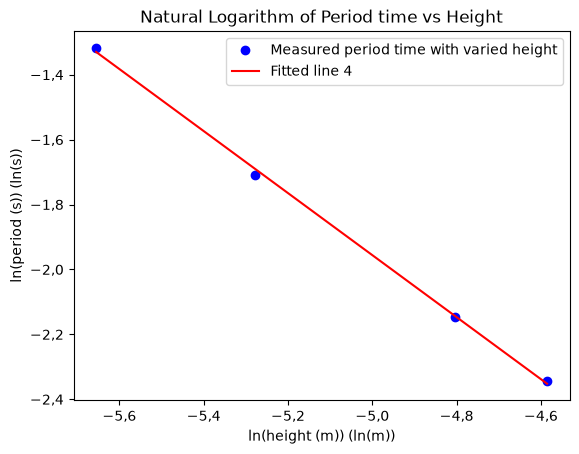

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Set pyplot to use Swedish locale for numeric formatting
import locale
_, axes = plt.subplots()
locale.setlocale(locale.LC_NUMERIC, ('sv_SE', 'UTF-8'))
axes.ticklabel_format(useLocale=True)

def linReg(x: np.ndarray, y: np.ndarray):
  """
  Performs linear regression on the given x and y data.
  x: independent variable (numpy array)
  y: dependent variable (numpy array)

  Returns: (k1, k2, u1, u2)
  k1: slope of the fitted line
  k2: intercept of the fitted line
  u1: uncertainty in the slope
  u2: uncertainty in the intercept
  """
  n = len(x)
  k1: int | float = (n*np.sum(x*y)-np.sum(x)*np.sum(y)) / ( n*np.sum(x**2)-np.sum(x)**2)
  k2: int | float = (np.sum(y) - (k1 * np.sum(x))) / n

  # Standard deviation for the regression
  dev = np.sqrt((1 / (n - 2)) * np.sum((y - (k1 * x) - k2) ** 2))
  meanX = np.mean(x)
  # Uncertainty in slope
  u1: int | float = dev * np.sqrt(1/np.sum((x - meanX) ** 2))
  # Uncertainty in intercept
  u2: int | float = dev * np.sqrt((1/n) + ((meanX ** 2) / np.sum((x - meanX) ** 2)))

  return (k1, k2, u1, u2)

# Fourth set of measured values; height (cm) and period time (s))
height_4 = np.array([0.35, 0.51, 0.82, 1.02])
period_4 = np.array([0.268, 0.181, 0.117, 0.096])
# Fourth constant value, measured in cm
length_4 = np.array([85.0, 85.05, 85.05, 85.0])
# Convert to base units (remove prefix)
height_4 *= 0.01
period_4 *= 1
length_4 *= 0.01

# Linearize by taking the natural logarithm of both values, then perform regression
slope, intercept, slope_uncertainty, intercept_uncertainty = linReg(np.log(height_4), np.log(period_4))

# Print slope and intercept; we mainly care about slope
print(f'slope 4: {slope} ± {slope_uncertainty:.2g}')
print(f'intercept 4: {intercept} ± {intercept_uncertainty:.2g}')

plt.plot(np.log(height_4), np.log(period_4), 'bo', label='Measured period time with varied height')
plt.plot(np.log(height_4), slope*np.log(height_4) + intercept, 'r-', label='Fitted line 4')
plt.title('Natural Logarithm of Period time vs Height')
plt.xlabel('ln(height (m)) (ln(m))')
plt.ylabel('ln(period (s)) (ln(s))')
plt.legend()
plt.show()

## Bestämning av resterande exponenter
Från mätserierna har vi att:
* $x_A = 0$
* $x_l = 2$
* $x_w = 0$
* $x_h = -1$

Lösning av ekvationssystemet från dimensionsanalysen ger oss de resterande tre exponenterna. Vi får att:
* $x_E = -0.5$
* $x_g = 0$
* $x_\rho = 0.5$

["Fysiska" labbanteckningar som pdf](./labbanteckningar.pdf)
!["Fysiska" labbanteckningar, sida 1](./labbanteckningar/labbanteckningar_page-0001.jpg)
!["Fysiska" labbanteckningar, sida 2](./labbanteckningar/labbanteckningar_page-0002.jpg)
!["Fysiska" labbanteckningar, sida 3](./labbanteckningar/labbanteckningar_page-0003.jpg)
!["Fysiska" labbanteckningar, sida 4](./labbanteckningar/labbanteckningar_page-0004.jpg)
!["Fysiska" labbanteckningar, sida 5](./labbanteckningar/labbanteckningar_page-0005.jpg)
!["Fysiska" labbanteckningar, sida 6](./labbanteckningar/labbanteckningar_page-0006.jpg)
!["Fysiska" labbanteckningar, sida 7](./labbanteckningar/labbanteckningar_page-0007.jpg)

## Erhållen formel
När framtagna exponenter stoppas in i ekvation (1) blir den resulterande formeln för periodtiden:
$$ T = k \cdot \frac{l^{2}}{h}\sqrt{\frac{\rho}{E}} \quad \mathrm{(9)} $$

## Bestämning av proportionalitetskonstanten
Vi behöver fortfarande bestämma proportionalitetskonstanten $k$. Notera att om vi sätter:
$$ x = \frac{l^{2}}{h}\sqrt{\frac{\rho}{E}} \quad \mathrm{(10)} $$
$$ y = T \quad \mathrm{(11)} $$
får vi ett linjärt samband $y = kx$. För varje mätning, i en mätserie, kan värden på $x$ och $y$ beräknas. Vi kan sedan plotta dessa $xy$-värden i en graf, och bestämma $k$ från riktningskoefficienten på en anpassad rät linje.

Vi beräknar $k$ på ovanstående sätt, med hjälp av mätvärdena från mätserie 2 och värdena på konstanterna som ges i metodavsnittet.

### Bestämning av $k$ från mätserie 2 (och 4?)
I figurerna nedan ges $xy$-grafen som fås med värdena från olika kombinationer av mätserier.

slope all: 6.507578725745726 ± 0.068
intercept all: 0.0019018004843469358 ± 0.0015


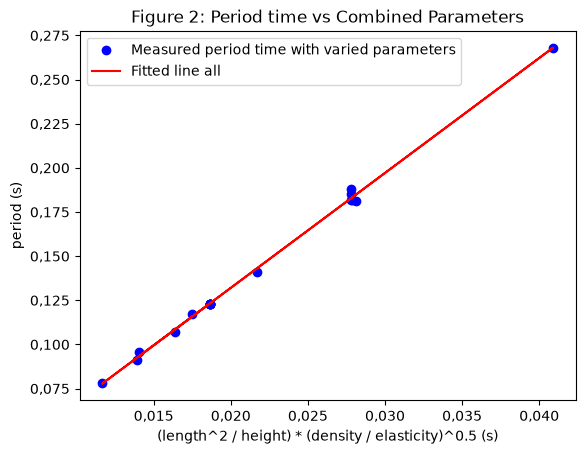

slope relevant: 6.4455746549403425 ± 0.076
intercept relevant: 0.0026620808090130036 ± 0.0017


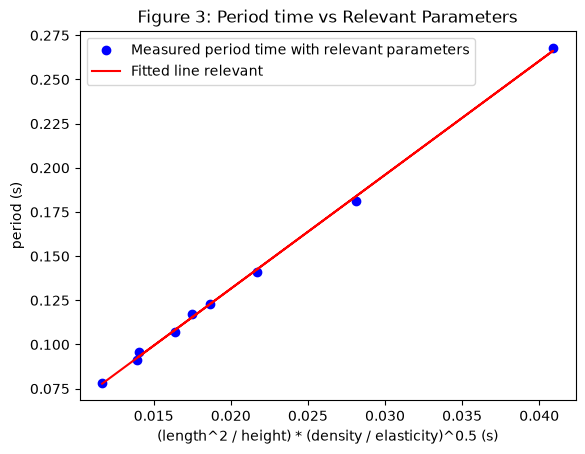

slope length only: 6.3681541067954655 ± 0.12
intercept length only: 0.0032293289574745867 ± 0.002


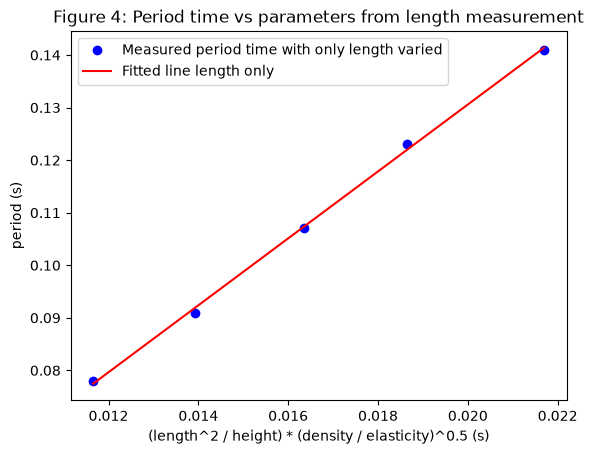

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Set pyplot to use Swedish locale for numeric formatting
import locale
_, axes = plt.subplots()
locale.setlocale(locale.LC_NUMERIC, ('sv_SE', 'UTF-8'))
axes.ticklabel_format(useLocale=True)

def linReg(x: np.ndarray, y: np.ndarray):
  """
  Performs linear regression on the given x and y data.
  x: independent variable (numpy array)
  y: dependent variable (numpy array)

  Returns: (k1, k2, u1, u2)
  k1: slope of the fitted line
  k2: intercept of the fitted line
  u1: uncertainty in the slope
  u2: uncertainty in the intercept
  """
  n = len(x)
  k1: int | float = (n*np.sum(x*y)-np.sum(x)*np.sum(y)) / ( n*np.sum(x**2)-np.sum(x)**2)
  k2: int | float = (np.sum(y) - (k1 * np.sum(x))) / n

  # Standard deviation for the regression
  dev = np.sqrt((1 / (n - 2)) * np.sum((y - (k1 * x) - k2) ** 2))
  meanX = np.mean(x)
  # Uncertainty in slope
  u1: int | float = dev * np.sqrt(1/np.sum((x - meanX) ** 2))
  # Uncertainty in intercept
  u2: int | float = dev * np.sqrt((1/n) + ((meanX ** 2) / np.sum((x - meanX) ** 2)))

  return (k1, k2, u1, u2)

# First set of measured values; varying Amplitude (cm) and measuring period time (s)
amplitude_1 = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
period_1 = np.array([0.123, 0.123, 0.123, 0.123, 0.123])
# First set of constant values, all 3 are measured in cm
length_1 = np.array([69.6 for _ in range(5)])
width_1 = np.array([2.02 for _ in range(5)])
height_1 = np.array([0.515 for _ in range(5)])
# Convert to base units (remove prefix)
amplitude_1 *= 0.01
period_1 *= 1
length_1 *= 0.01
width_1 *= 0.01
height_1 *= 0.01

# Since the slope for the first set of measurements is almost 0, we assume the period time is independent of the amplitude.
# Amplitude will be ignored for future measurements.


# Second set of measured values; length (cm) and period time (s)
length_2 = np.array([55.05, 60.15, 65.2, 69.6, 75.1])
period_2 = np.array([0.078, 0.091, 0.107, 0.123, 0.141])
# Second set of constant values, both are measured in cm
width_2 = np.array([2.02 for _ in range(5)])
height_2 = np.array([0.515 for _ in range(5)])
# Convert to base units (remove prefix)
length_2 *= 0.01
period_2 *= 1
width_2 *= 0.01
height_2 *= 0.01


# Third set of measured values; width (cm) and period time (s)
width_3 = np.array([2.04, 3.02, 4.03, 5.00])
period_3 = np.array([0.182, 0.185, 0.182, 0.188])
# Third set of constant values, both are measured in cm
# Length varies slightly due to human error in setting up the experiment
length_3 = np.array([70.15, 70.05, 70.1, 70.1])
height_3 = np.array([0.35 for _ in range(4)])
# Convert to base units (remove prefix)
width_3 *= 0.01
period_3 *= 1
length_3 *= 0.01
height_3 *= 0.01

# Since the slope for the third set of measurements is almost 0, we assume the period time is independent of the width.
# Width will be ignored for future measurements.


# Fourth set of measured values; height (cm) and period time (s))
height_4 = np.array([0.35, 0.51, 0.82, 1.02])
period_4 = np.array([0.268, 0.181, 0.117, 0.096])
# Fourth constant value, measured in cm
length_4 = np.array([85.0, 85.05, 85.05, 85.0])
# Convert to base units (remove prefix)
height_4 *= 0.01
period_4 *= 1
length_4 *= 0.01

# Extra exponents calculated rather than measured
gravity_exponent: float = 0
density_exponent: float = 0.5
elasticity_exponent: float = -0.5

# Values for the above constants, given by lab instructor
# Gravity in Sundsvall
gravity: float = 9.82 # m/s^2
# Density of steel
density: float = 7850 # kg/m^3
# Elasticity of steel
elasticity: float = 200 # GPa
#Convert elasticity to Pa
elasticity *= 1e9

# Copy in formula for calculating constant
all_periods = np.concatenate([period_1, period_2, period_3, period_4])

all_length = np.concatenate([length_1, length_2, length_3, length_4])
all_height = np.concatenate([height_1, height_2, height_3, height_4])

x = (all_length**2 / all_height) * np.sqrt(density / elasticity)

slope, intercept, slope_uncertainty, intercept_uncertainty = linReg(x, all_periods)
print(f'slope all: {slope} ± {slope_uncertainty:.2g}')
print(f'intercept all: {intercept} ± {intercept_uncertainty:.2g}')

plt.plot(x, all_periods, 'bo', label='Measured period time with varied parameters')
plt.plot(x, slope*x + intercept, 'r-', label='Fitted line all')
plt.title('Figure 2: Period time vs Combined Parameters')
plt.xlabel('(length^2 / height) * (density / elasticity)^0.5 (s)')
plt.ylabel('period (s)')
plt.legend()
plt.show()

relevant_periods = np.concatenate([period_2, period_4])
relevant_lengths = np.concatenate([length_2, length_4])
relevant_heights = np.concatenate([height_2, height_4])

relevant_x = (relevant_lengths**2 / relevant_heights) * np.sqrt(density / elasticity)

slope, intercept, slope_uncertainty, intercept_uncertainty = linReg(relevant_x, relevant_periods)
print(f'slope relevant: {slope} ± {slope_uncertainty:.2g}')
print(f'intercept relevant: {intercept} ± {intercept_uncertainty:.2g}')

plt.plot(relevant_x, relevant_periods, 'bo', label='Measured period time with relevant parameters')
plt.plot(relevant_x, slope*relevant_x + intercept, 'r-', label='Fitted line relevant')
plt.title('Figure 3: Period time vs Relevant Parameters')
plt.xlabel('(length^2 / height) * (density / elasticity)^0.5 (s)')
plt.ylabel('period (s)')
plt.legend()
plt.show()

# Based on only length
x = (length_2**2 / height_2) * np.sqrt(density / elasticity)

slope, intercept, slope_uncertainty, intercept_uncertainty = linReg(x, period_2)
print(f'slope length only: {slope} ± {slope_uncertainty:.2g}')
print(f'intercept length only: {intercept} ± {intercept_uncertainty:.2g}')

plt.plot(x, period_2, 'bo', label='Measured period time with only length varied')
plt.plot(x, slope*x + intercept, 'r-', label='Fitted line length only')
plt.title('Figure 4: Period time vs parameters from length measurement')
plt.xlabel('(length^2 / height) * (density / elasticity)^0.5 (s)')
plt.ylabel('period (s)')
plt.legend()
plt.show()

Från den anpassade räta linjen i figur 4 får vi att $k=6.37(12)$. Detta $k$-värde har en relativt låg konfidensnivå på ~68%. För att uppnå en högre konfidensnivå multipliceras mätosäkerheten med $3.18$ för att öka vårt konfidensintervall med 5 mätningar till 95%, enligt given tabell. Detta ger oss att $5.99 < \mathrm{k} < 6.75$

Alternativt kan vi räkna ut k utifrån figur 3, vilken innehåller 9 mätvärden, där vi får att $k=6.446(76)$
Här vill vi istället uppnå en konfidensnivå på 99% med 9 mätpunkter, vilket kräver att vi multiplicerar vår mätosäkerhet med $3.50$. Det ger oss att $6.18 < k < 6.72$.

Konstanterna som har använts kan ha viss mätosäkerhet, och därför påverkan på resultatet vi fått. $g$ har en relativt låg mätosäkerhet och har ingen påverkan på resultatet. $\rho$ har antagligen en mätosäkerhet på ca. 1%, men $E$ verkar kunna ha en osäkerhet på uppemot 10%, beroende på vilken typ av stål som använts i experimentet.

## Teoretisk formel
Enligt givna uppgifter är den teoretiska formeln för periodtiden:
$$ T = k \cdot \frac{l^2}{h} \sqrt{\frac{\rho}{E}} \quad \mathrm{(12)} $$
där det teoretiska värdet på $k$ är 6.19.

## Diskussion
Vår formel blev densamma som den teoretiska formeln men vårt $k$-värde blev något högt. Med visst utökade konfidensintervall täcker vi däremot det teoretiska värdet på $k$. Vårt höga värde på $k$ kan bland annat bero på att vi skattade medelvärdet för alla individuella mätningar av periodtiden, vilket vi tror kan ha skattats något högre än det faktiska medelvärdet, vilket i sin tur skulle ha direkt påverkan på $k$-värdet. Vi har också inte inkluderat någon kombinerad mätosäkerhet, något som kanske skulle vara relevant med våra konstanta variabler.

För att förbättra labben hade det vara bra om vi hade möjlighet att göra fler mätningar, främst i form av fler stänger med olika tjocklek. Det hade också hjälpt om vi haft möjligheten att spara alla mätvärden för periodtiden digitalt istället för att behöva skatta ett genomsnitt. Att veta vilken typ (eller vilka typer) av stål hade också hjälpt, då vi kunde fått mer exakta värden för densitet och elasticitet. Ett måttband (som det stod i instruktionerna) hade antagligen varit bättre än den linjal vi behövde använda under labben.

Facit rekommenderar att vi ska söka på "free vibration of cantilever beam".

Fullständig loggbok med bilder, "fysiska" anteckningar, och kod finns på [GitHub](https://github.com/noelle-loov/examining_lab)